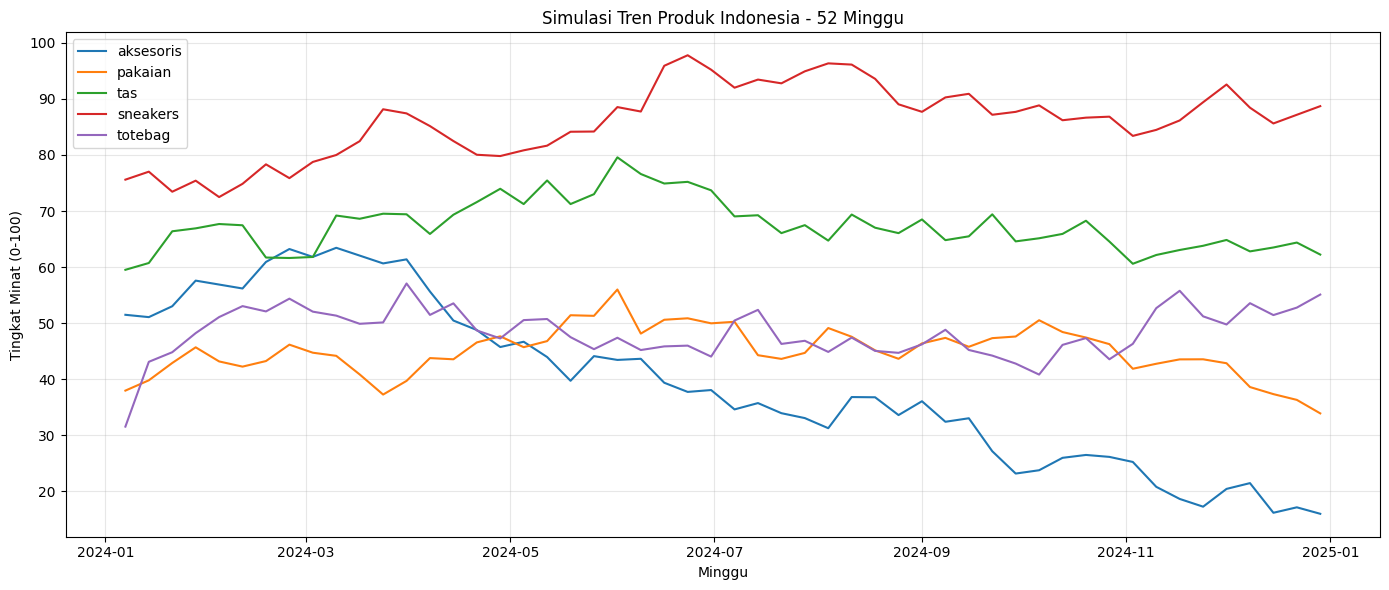

5 data terakhir:
            aksesoris    pakaian        tas   sneakers    totebag
2024-12-01  20.437180  42.850126  64.840712  92.567113  49.763131
2024-12-08  21.468035  38.604013  62.800638  88.434105  53.563865
2024-12-15  16.178914  37.342077  63.497399  85.620630  51.440856
2024-12-22  17.151166  36.313934  64.376616  87.165736  52.772315
2024-12-29  15.995919  33.907102  62.233562  88.707094  55.096217


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data simulasi tren produk (mirip Google Trends, skala 0-100)
np.random.seed(42)
dates = pd.date_range(start='2024-01', periods=52, freq='W')

data = pd.DataFrame({
    'aksesoris':     np.clip(50 + np.cumsum(np.random.randn(52)*3), 10, 100),
    'pakaian':     np.clip(40 + np.cumsum(np.random.randn(52)*3), 10, 100),
    'tas':     np.clip(60 + np.cumsum(np.random.randn(52)*3), 10, 100),
    'sneakers':  np.clip(70 + np.cumsum(np.random.randn(52)*3), 10, 100),
    'totebag':   np.clip(30 + np.cumsum(np.random.randn(52)*3), 10, 100),
}, index=dates)

# Tampilkan grafik
plt.figure(figsize=(14, 6))
for col in data.columns:
    plt.plot(data.index, data[col], label=col)

plt.title('Simulasi Tren Produk Indonesia - 52 Minggu')
plt.xlabel('Minggu')
plt.ylabel('Tingkat Minat (0-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("5 data terakhir:")
print(data.tail())

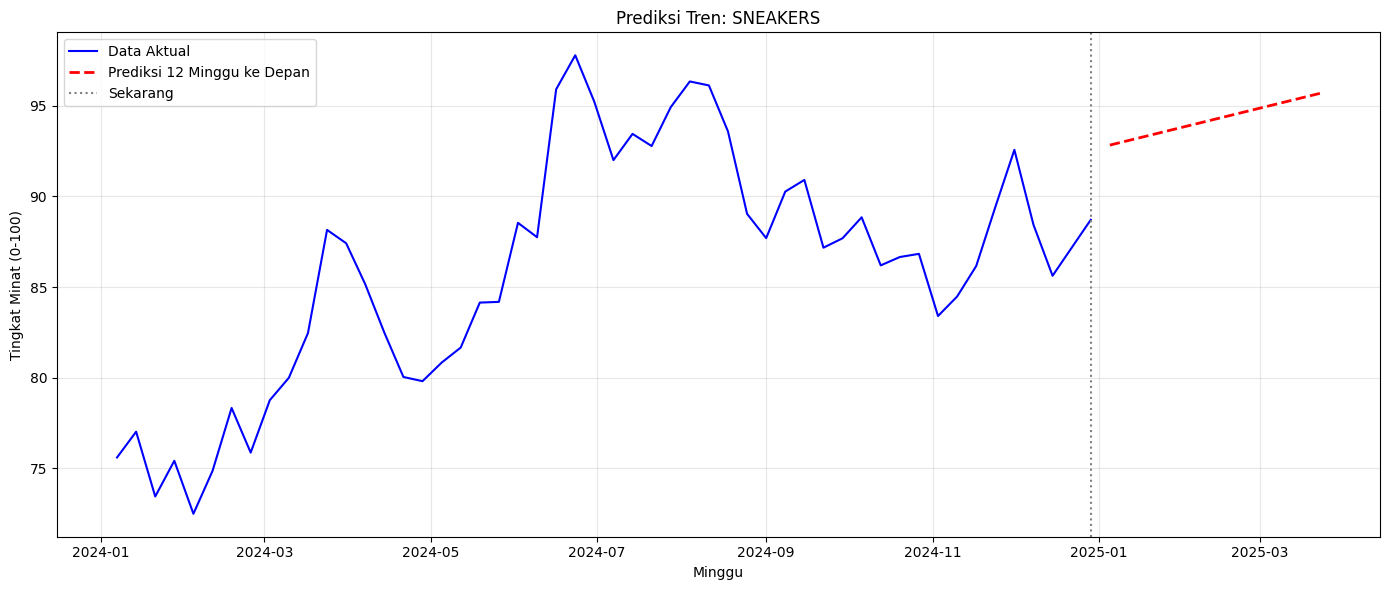


Prediksi tren sneakers 12 minggu ke depan:
Minggu 1 (2025-01-05): 92.8 ⬆️ Naik
Minggu 2 (2025-01-12): 93.1 ⬆️ Naik
Minggu 3 (2025-01-19): 93.3 ⬆️ Naik
Minggu 4 (2025-01-26): 93.6 ⬆️ Naik
Minggu 5 (2025-02-02): 93.9 ⬆️ Naik
Minggu 6 (2025-02-09): 94.1 ⬆️ Naik
Minggu 7 (2025-02-16): 94.4 ⬆️ Naik
Minggu 8 (2025-02-23): 94.6 ⬆️ Naik
Minggu 9 (2025-03-02): 94.9 ⬆️ Naik
Minggu 10 (2025-03-09): 95.2 ⬆️ Naik
Minggu 11 (2025-03-16): 95.4 ⬆️ Naik
Minggu 12 (2025-03-23): 95.7 ⬆️ Naik


In [3]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Pilih satu produk untuk diprediksi dulu
produk = 'sneakers'
series = data[produk].values

# Buat fitur waktu (angka 0, 1, 2, ...)
X = np.arange(len(series)).reshape(-1, 1)
y = series

# Train model
model = LinearRegression()
model.fit(X, y)

# Prediksi 12 minggu ke depan
future_X = np.arange(len(series), len(series) + 12).reshape(-1, 1)
future_pred = model.predict(future_X)
future_dates = pd.date_range(start=data.index[-1], periods=13, freq='W')[1:]

# Visualisasi
plt.figure(figsize=(14, 6))
plt.plot(data.index, series, label='Data Aktual', color='blue')
plt.plot(future_dates, future_pred, label='Prediksi 12 Minggu ke Depan', 
         color='red', linestyle='--', linewidth=2)
plt.axvline(x=data.index[-1], color='gray', linestyle=':', label='Sekarang')
plt.title(f'Prediksi Tren: {produk.upper()}')
plt.xlabel('Minggu')
plt.ylabel('Tingkat Minat (0-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPrediksi tren {produk} 12 minggu ke depan:")
for i, (date, pred) in enumerate(zip(future_dates, future_pred)):
    arah = "⬆️ Naik" if pred > series[-1] else "⬇️ Turun"
    print(f"Minggu {i+1} ({date.strftime('%Y-%m-%d')}): {pred:.1f} {arah}")

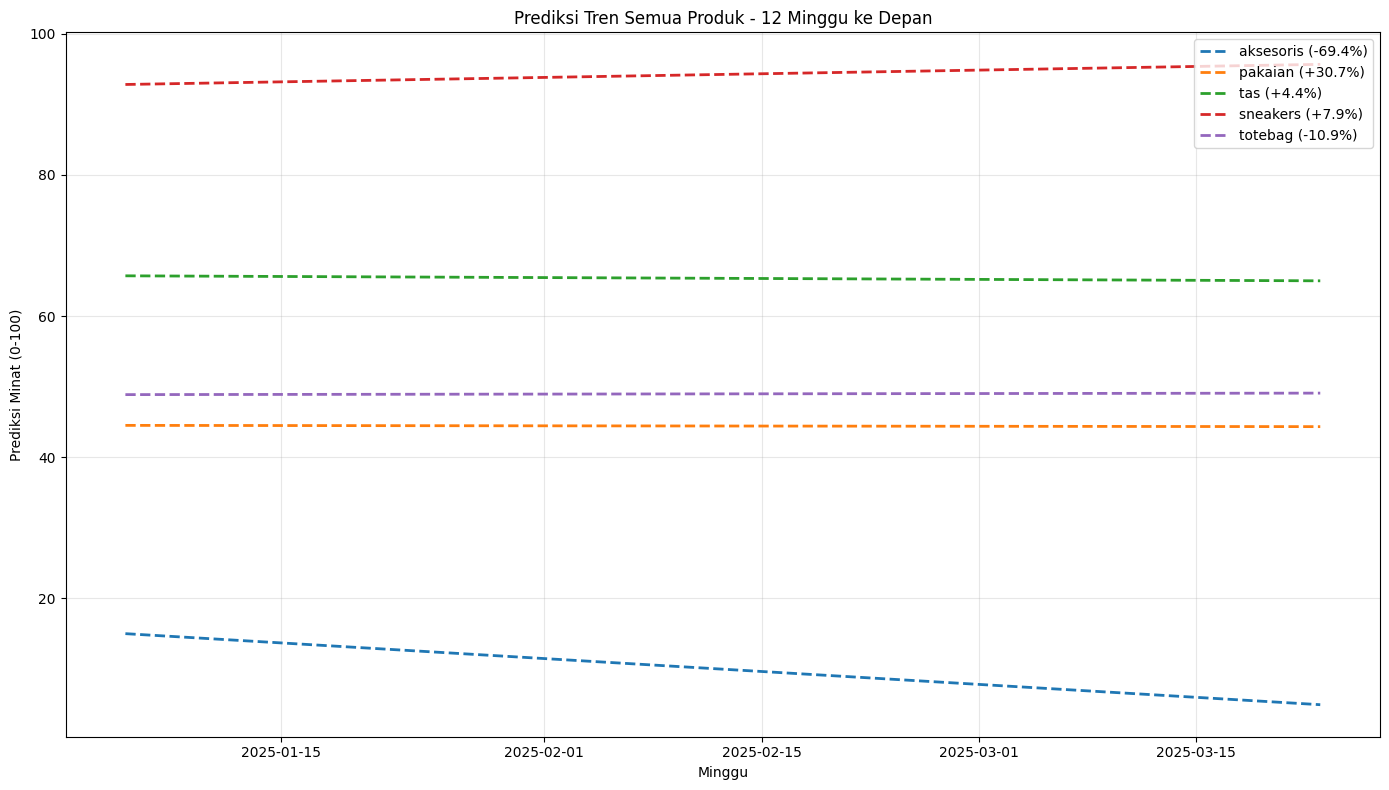


🏆 RANKING PRODUK - Potensi Naik Tren:
----------------------------------------
1. PAKAIAN      +30.7% 🔥 RECOMMENDED
2. SNEAKERS     +7.9% 🔥 RECOMMENDED
3. TAS          +4.4% 🔥 RECOMMENDED
4. TOTEBAG      -10.9% ⚠️ Hindari
5. AKSESORIS    -69.4% ⚠️ Hindari


In [4]:
# Prediksi semua produk sekaligus
plt.figure(figsize=(14, 8))
hasil_prediksi = {}

for produk in data.columns:
    series = data[produk].values
    X = np.arange(len(series)).reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(X, series)
    
    future_X = np.arange(len(series), len(series) + 12).reshape(-1, 1)
    future_pred = model.predict(future_X)
    future_dates = pd.date_range(start=data.index[-1], periods=13, freq='W')[1:]
    
    # Hitung % perubahan
    perubahan = ((future_pred[-1] - series[-1]) / series[-1]) * 100
    hasil_prediksi[produk] = perubahan
    
    plt.plot(future_dates, future_pred, linestyle='--', linewidth=2, label=f'{produk} ({perubahan:+.1f}%)')

plt.title('Prediksi Tren Semua Produk - 12 Minggu ke Depan')
plt.xlabel('Minggu')
plt.ylabel('Prediksi Minat (0-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ranking produk
print("\n🏆 RANKING PRODUK - Potensi Naik Tren:")
print("-" * 40)
ranking = sorted(hasil_prediksi.items(), key=lambda x: x[1], reverse=True)
for i, (produk, pct) in enumerate(ranking, 1):
    status = "🔥 RECOMMENDED" if pct > 0 else "⚠️ Hindari"
    print(f"{i}. {produk.upper():12} {pct:+.1f}% {status}")

In [1]:
from pytrends.request import TrendReq
import time

print("Mencoba koneksi ke Google Trends...")
time.sleep(3)

pytrends = TrendReq(hl='id-ID', tz=420)
time.sleep(5)

pytrends.build_payload(['sneakers'], timeframe='today 3-m', geo='ID')
time.sleep(5)

data_asli = pytrends.interest_over_time()
print("✅ Berhasil! Data asli dari Google Trends:")
print(data_asli.tail())

Mencoba koneksi ke Google Trends...


TooManyRequestsError: The request failed: Google returned a response with code 429

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca file CSV dari Google Trends
# Skip 1 baris pertama
df = pd.read_csv('../data/Data_TrenProdukSneakers.csv', skiprows=1)

# Lihat isi datanya dulu
print("Isi data:")
print(df.head(10))
print("\nNama kolom:", df.columns.tolist())
print("Jumlah data:", len(df))

Isi data:
   2025-05-04  25
0  2025-05-11  22
1  2025-05-18  21
2  2025-05-25  20
3  2025-06-01  20
4  2025-06-08  22
5  2025-06-15  25
6  2025-06-22  27
7  2025-06-29  28
8  2025-07-06  28
9  2025-07-13  23

Nama kolom: ['2025-05-04', '25']
Jumlah data: 52


Data setelah dirapikan:
            sneakers
tanggal             
2026-04-05        31
2026-04-12        27
2026-04-19        21
2026-04-26        21
2026-05-03        21


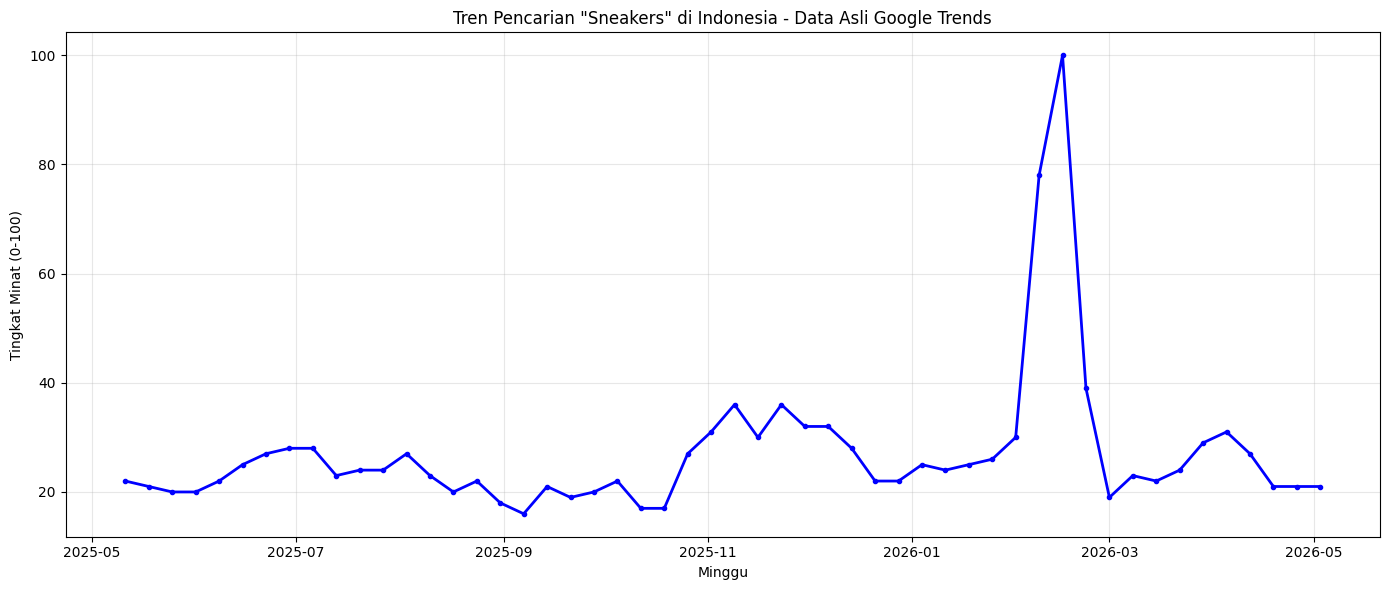


Rata-rata minat: 27.1
Tertinggi: 100 pada 2026-02-15
Terendah: 16 pada 2025-09-07


In [3]:
# Rapikan kolom
df.columns = ['tanggal', 'sneakers']
df['tanggal'] = pd.to_datetime(df['tanggal'])
df['sneakers'] = pd.to_numeric(df['sneakers'], errors='coerce')
df = df.set_index('tanggal')

print("Data setelah dirapikan:")
print(df.tail())

# Visualisasi data asli
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['sneakers'], color='blue', linewidth=2, marker='o', markersize=3)
plt.title('Tren Pencarian "Sneakers" di Indonesia - Data Asli Google Trends')
plt.xlabel('Minggu')
plt.ylabel('Tingkat Minat (0-100)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRata-rata minat: {df['sneakers'].mean():.1f}")
print(f"Tertinggi: {df['sneakers'].max()} pada {df['sneakers'].idxmax().strftime('%Y-%m-%d')}")
print(f"Terendah: {df['sneakers'].min()} pada {df['sneakers'].idxmin().strftime('%Y-%m-%d')}")

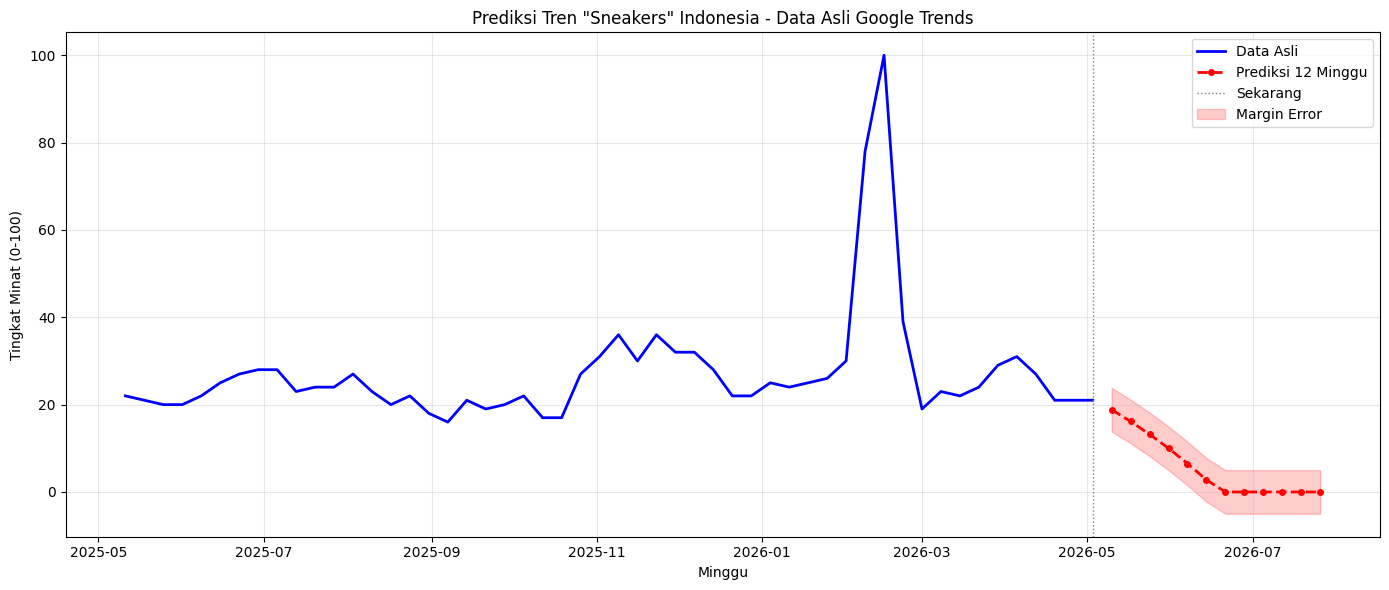


📊 PREDIKSI TREN SNEAKERS - 12 Minggu ke Depan:
--------------------------------------------------
Minggu  1 (2026-05-10): 18.8 ⬇️ Turun
Minggu  2 (2026-05-17): 16.1 ⬇️ Turun
Minggu  3 (2026-05-24): 13.2 ⬇️ Turun
Minggu  4 (2026-05-31): 10.0 ⬇️ Turun
Minggu  5 (2026-06-07): 6.5 ⬇️ Turun
Minggu  6 (2026-06-14): 2.8 ⬇️ Turun
Minggu  7 (2026-06-21): 0.0 ⬇️ Turun
Minggu  8 (2026-06-28): 0.0 ⬇️ Turun
Minggu  9 (2026-07-05): 0.0 ⬇️ Turun
Minggu 10 (2026-07-12): 0.0 ⬇️ Turun
Minggu 11 (2026-07-19): 0.0 ⬇️ Turun
Minggu 12 (2026-07-26): 0.0 ⬇️ Turun

🏆 Kesimpulan: Tren sneakers diprediksi TURUN 📉
   Dari 18.8 → 0.0


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# Siapkan data
X = np.arange(len(df)).reshape(-1, 1)
y = df['sneakers'].values

# Pakai Polynomial Regression (lebih bagus dari linear untuk tren)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# Prediksi 12 minggu ke depan
future_X = np.arange(len(df), len(df) + 12).reshape(-1, 1)
future_X_poly = poly.transform(future_X)
future_pred = model.predict(future_X_poly)
future_pred = np.clip(future_pred, 0, 100)  # batas 0-100
future_dates = pd.date_range(start=df.index[-1], periods=13, freq='W')[1:]

# Visualisasi
plt.figure(figsize=(14, 6))
plt.plot(df.index, y, color='blue', linewidth=2, label='Data Asli')
plt.plot(future_dates, future_pred, color='red', linewidth=2, 
         linestyle='--', marker='o', markersize=4, label='Prediksi 12 Minggu')
plt.axvline(x=df.index[-1], color='gray', linestyle=':', linewidth=1, label='Sekarang')
plt.fill_between(future_dates, future_pred - 5, future_pred + 5, 
                 alpha=0.2, color='red', label='Margin Error')
plt.title('Prediksi Tren "Sneakers" Indonesia - Data Asli Google Trends')
plt.xlabel('Minggu')
plt.ylabel('Tingkat Minat (0-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Output prediksi
print("\n📊 PREDIKSI TREN SNEAKERS - 12 Minggu ke Depan:")
print("-" * 50)
for i, (date, pred) in enumerate(zip(future_dates, future_pred), 1):
    arah = "🔥 Naik" if pred > future_pred[max(0,i-2)] else "⬇️ Turun"
    print(f"Minggu {i:2d} ({date.strftime('%Y-%m-%d')}): {pred:.1f} {arah}")

tren_keseluruhan = "NAIK 📈" if future_pred[-1] > future_pred[0] else "TURUN 📉"
print(f"\n🏆 Kesimpulan: Tren sneakers diprediksi {tren_keseluruhan}")
print(f"   Dari {future_pred[0]:.1f} → {future_pred[-1]:.1f}")

Rata-rata normal (tanpa spike): 24.6


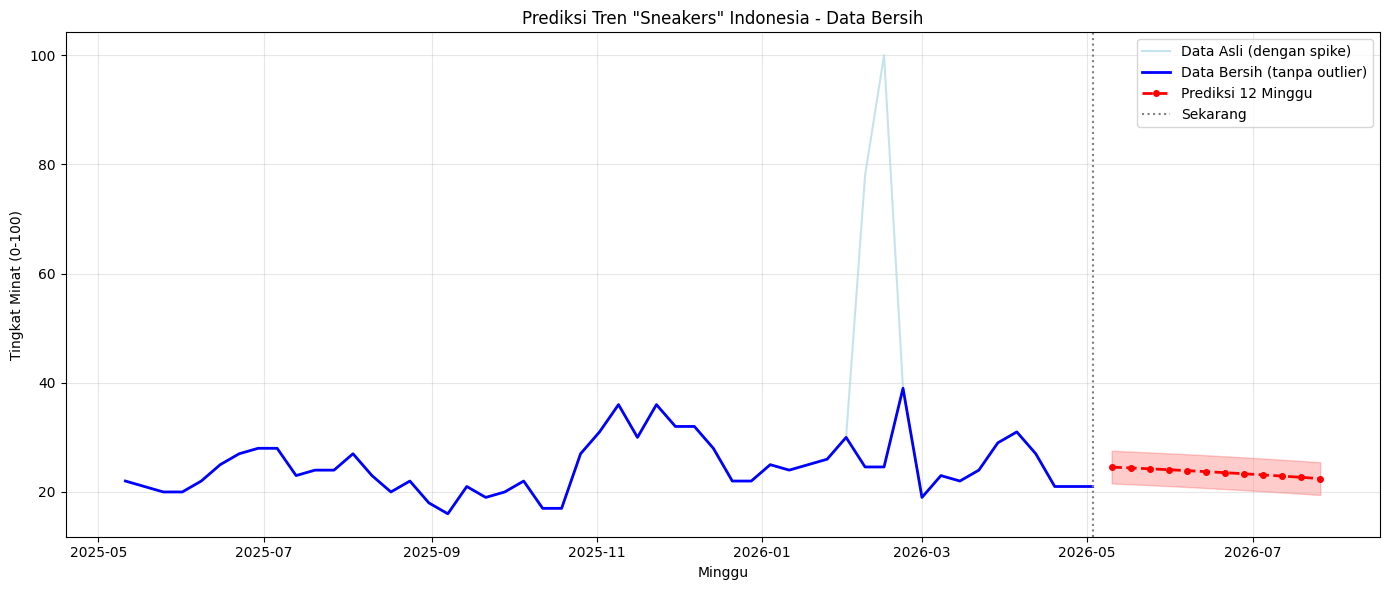


📊 PREDIKSI TREN SNEAKERS - 12 Minggu ke Depan:
--------------------------------------------------
Minggu  1 (2026-05-10): 24.6 🔥 Naik
Minggu  2 (2026-05-17): 24.4 ⬇️ Turun
Minggu  3 (2026-05-24): 24.2 ⬇️ Turun
Minggu  4 (2026-05-31): 24.1 ⬇️ Turun
Minggu  5 (2026-06-07): 23.9 ⬇️ Turun
Minggu  6 (2026-06-14): 23.7 ⬇️ Turun
Minggu  7 (2026-06-21): 23.5 ⬇️ Turun
Minggu  8 (2026-06-28): 23.3 ⬇️ Turun
Minggu  9 (2026-07-05): 23.1 ⬇️ Turun
Minggu 10 (2026-07-12): 22.9 ⬇️ Turun
Minggu 11 (2026-07-19): 22.7 ⬇️ Turun
Minggu 12 (2026-07-26): 22.4 ⬇️ Turun

🏆 Kesimpulan: Tren sneakers diprediksi TURUN 📉
   Dari 24.6 → 22.4


In [6]:
# Filter spike ekstrem dulu sebelum prediksi
df_clean = df.copy()
df_clean['sneakers'] = df_clean['sneakers'].astype(float)  # fix error

# Ganti nilai di atas 60 dengan rata-rata sekitarnya
mean_normal = df_clean[df_clean['sneakers'] < 60]['sneakers'].mean()
df_clean.loc[df_clean['sneakers'] > 60, 'sneakers'] = mean_normal

print(f"Rata-rata normal (tanpa spike): {mean_normal:.1f}")

# Prediksi ulang dengan data bersih
X = np.arange(len(df_clean)).reshape(-1, 1)
y = df_clean['sneakers'].values

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

future_X = np.arange(len(df_clean), len(df_clean) + 12).reshape(-1, 1)
future_X_poly = poly.transform(future_X)
future_pred = model.predict(future_X_poly)
future_pred = np.clip(future_pred, 0, 100)
future_dates = pd.date_range(start=df_clean.index[-1], periods=13, freq='W')[1:]

# Visualisasi
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['sneakers'], color='lightblue', linewidth=1.5,
         label='Data Asli (dengan spike)', alpha=0.7)
plt.plot(df_clean.index, df_clean['sneakers'], color='blue', linewidth=2,
         label='Data Bersih (tanpa outlier)')
plt.plot(future_dates, future_pred, color='red', linewidth=2,
         linestyle='--', marker='o', markersize=4, label='Prediksi 12 Minggu')
plt.axvline(x=df_clean.index[-1], color='gray', linestyle=':', label='Sekarang')
plt.fill_between(future_dates, future_pred - 3, future_pred + 3,
                 alpha=0.2, color='red')
plt.title('Prediksi Tren "Sneakers" Indonesia - Data Bersih')
plt.xlabel('Minggu')
plt.ylabel('Tingkat Minat (0-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 PREDIKSI TREN SNEAKERS - 12 Minggu ke Depan:")
print("-" * 50)
for i, (date, pred) in enumerate(zip(future_dates, future_pred), 1):
    arah = "🔥 Naik" if i == 1 or pred > future_pred[i-2] else "⬇️ Turun"
    print(f"Minggu {i:2d} ({date.strftime('%Y-%m-%d')}): {pred:.1f} {arah}")

tren = "NAIK 📈" if future_pred[-1] > future_pred[0] else "TURUN 📉"
print(f"\n🏆 Kesimpulan: Tren sneakers diprediksi {tren}")
print(f"   Dari {future_pred[0]:.1f} → {future_pred[-1]:.1f}")

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Sesuaikan nama file dengan yang ada di folder
file_mapping = {
    'aksesoris': 'Data_TrenProdukAksesoris.csv',
    'pakaian':   'Data_TrenProdukPakaian.csv',
    'sneakers':  'Data_TrenProdukSneakers.csv',
    'tas':       'Data_TrenProdukTas.csv',
    'totebag':   'Data_TrenProdukTotebag.csv',
}

semua_data = {}

# Baca semua CSV
for produk, filename in file_mapping.items():
    df_temp = pd.read_csv(f'../data/{filename}', skiprows=1)
    df_temp.columns = ['tanggal', produk]
    df_temp['tanggal'] = pd.to_datetime(df_temp['tanggal'])
    df_temp[produk] = pd.to_numeric(df_temp[produk], errors='coerce').astype(float)
    df_temp = df_temp.set_index('tanggal')
    semua_data[produk] = df_temp

# Gabung semua jadi satu dataframe
df_all = pd.concat(semua_data.values(), axis=1)
print("✅ Semua data berhasil digabung!")
print(f"Total: {len(df_all)} minggu, {len(df_all.columns)} produk")
print("\n5 data terakhir:")
print(df_all.tail())

✅ Semua data berhasil digabung!
Total: 52 minggu, 5 produk

5 data terakhir:
            aksesoris  pakaian  sneakers   tas  totebag
tanggal                                                
2026-04-05       74.0     72.0      31.0  79.0     81.0
2026-04-12       74.0     75.0      27.0  78.0     91.0
2026-04-19       74.0     83.0      21.0  77.0     86.0
2026-04-26       72.0     72.0      21.0  76.0     81.0
2026-05-03       74.0     75.0      21.0  77.0     80.0


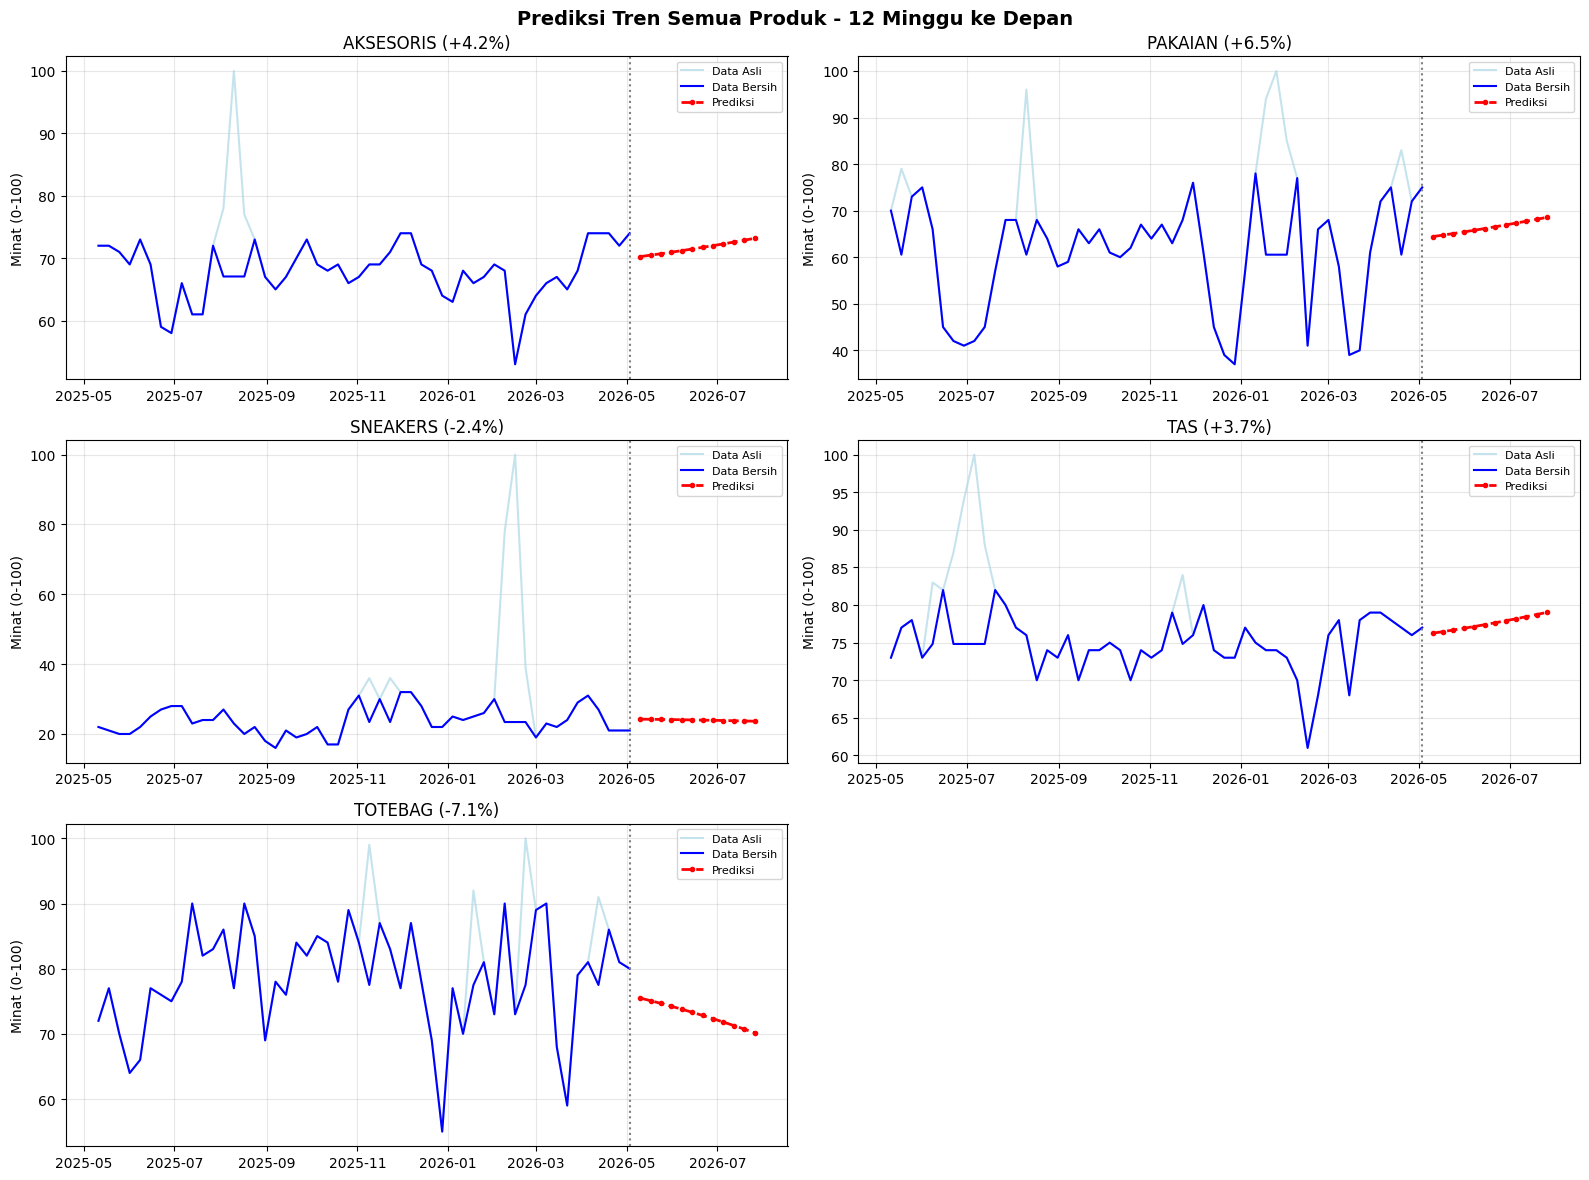


🏆 RANKING PRODUK - POTENSI TREN:
1. PAKAIAN      +6.5%  🔥 RECOMMENDED
2. AKSESORIS    +4.2%  🔥 RECOMMENDED
3. TAS          +3.7%  🔥 RECOMMENDED
4. SNEAKERS     -2.4%  ⚠️  HINDARI
5. TOTEBAG      -7.1%  ⚠️  HINDARI

💡 KESIMPULAN DECISION MAKING:
   Produk paling potensial: PAKAIAN (+6.5%)


In [9]:
# Bersihkan outlier semua produk
df_clean = df_all.copy()
for col in df_clean.columns:
    df_clean[col] = df_clean[col].astype(float)
    mean_normal = df_clean[col][df_clean[col] < df_clean[col].quantile(0.9)].mean()
    df_clean.loc[df_clean[col] > df_clean[col].quantile(0.9), col] = mean_normal

# Prediksi semua produk
hasil_prediksi = {}
future_dates = pd.date_range(start=df_clean.index[-1], periods=13, freq='W')[1:]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, produk in enumerate(df_clean.columns):
    X = np.arange(len(df_clean)).reshape(-1, 1)
    y = df_clean[produk].values

    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(X_poly, y)

    future_X = poly.transform(np.arange(len(df_clean), len(df_clean)+12).reshape(-1,1))
    future_pred = np.clip(model.predict(future_X), 0, 100)
    
    perubahan = ((future_pred[-1] - future_pred[0]) / future_pred[0]) * 100
    hasil_prediksi[produk] = {
        'prediksi_akhir': future_pred[-1],
        'prediksi_awal': future_pred[0],
        'perubahan_pct': perubahan,
        'pred_values': future_pred
    }

    # Plot per produk
    axes[i].plot(df_all.index, df_all[produk], color='lightblue', 
                 alpha=0.7, label='Data Asli')
    axes[i].plot(df_clean.index, df_clean[produk], color='blue', 
                 linewidth=1.5, label='Data Bersih')
    axes[i].plot(future_dates, future_pred, color='red', linewidth=2,
                 linestyle='--', marker='o', markersize=3, label='Prediksi')
    axes[i].axvline(x=df_clean.index[-1], color='gray', linestyle=':')
    axes[i].set_title(f'{produk.upper()} ({perubahan:+.1f}%)')
    axes[i].set_ylabel('Minat (0-100)')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Prediksi Tren Semua Produk - 12 Minggu ke Depan', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Ranking akhir
print("\n🏆 RANKING PRODUK - POTENSI TREN:")
print("=" * 50)
ranking = sorted(hasil_prediksi.items(), key=lambda x: x[1]['perubahan_pct'], reverse=True)
for i, (produk, info) in enumerate(ranking, 1):
    status = "🔥 RECOMMENDED" if info['perubahan_pct'] > 0 else "⚠️  HINDARI"
    print(f"{i}. {produk.upper():12} {info['perubahan_pct']:+.1f}%  {status}")

print("\n💡 KESIMPULAN DECISION MAKING:")
top = ranking[0]
print(f"   Produk paling potensial: {top[0].upper()} ({top[1]['perubahan_pct']:+.1f}%)")